# Game 1 – Optimal Market-Neutral Trading

This notebook implements Game 1 of the ESILV Commodities Trading Project.

The objective is to implement a market-neutral trading strategy based on price divergences between related assets.

The idea of pair trading is to exploit temporary price deviations between assets that usually move together. When the spread between two assets becomes abnormally large, we open a long/short position expecting the prices to converge again.

The dataset used in this project contains several assets related to the Palm Oil ecosystem, including agricultural companies and commodity ETFs.

The main steps of this notebook are:

1. Load and inspect the dataset  
2. Split the data into formation and trading periods  
3. Perform correlation and cointegration tests  
4. Select trading pairs  
5. Build the spread and compute z-scores  
6. Generate trading signals  
7. Backtest the strategy

In [ ]:
# Install required libraries

!pip install yfinance statsmodels gurobipy --quiet

## Import Libraries

In this section we import the Python libraries required for the analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from statsmodels.tsa.stattools import coint
import gurobipy as gp
from gurobipy import GRB

plt.style.use("default")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

## Load the Dataset

The dataset was previously created using historical market data from Yahoo Finance.

It contains daily closing prices for several assets related to the Palm Oil sector, including agricultural companies and commodity ETFs.

The dataset will be uploaded manually.

In [ ]:
# Upload dataset
uploaded = files.upload()

Saving palm_oil_dataset1.csv to palm_oil_dataset1 (1).csv


## Read and Inspect the Dataset

After uploading the dataset, we load it into a pandas DataFrame.

We also check

- the number of assets
- the date range
- the structure of the data

In [ ]:
file_name = "palm_oil_dataset1.csv"

data = pd.read_csv(file_name, index_col=0, parse_dates=True)
data = data.sort_index()

print("Dataset shape:", data.shape)
print("Start date:", data.index.min())
print("End date:", data.index.max())

data.head()

Dataset shape: (1869, 15)
Start date: 2015-01-02 00:00:00
End date: 2022-11-21 00:00:00


,5JS.SI,AALI.JK,BWPT.JK,DBA,E5H.SI,EB5.SI,LSIP.JK,MOO,P8Z.SI,RJA,SIMP.JK,SMAR.JK,SSMS.JK,TBLA.JK,UNSP.JK
Date,,,,,,,,,,,,,,,
2015-01-02,0.615186,16904.500000,397.0,21.180376,0.337494,1.239170,1323.021606,41.827995,0.560284,7.2900,580.742249,5272.602539,1274.376587,429.719788,500.0
2015-01-05,0.606759,16973.289062,395.0,21.438255,0.326489,1.229203,1340.384155,41.030972,0.560284,7.4300,576.681091,4565.301758,1289.457764,426.835602,500.0
2015-01-06,0.602545,16715.332031,390.0,21.584387,0.330158,1.225881,1319.549194,40.927353,0.560284,7.4301,568.558716,4404.551758,1289.457764,423.951630,500.0
2015-01-07,0.602545,16990.486328,382.0,21.481236,0.333826,1.255780,1329.966553,41.453396,0.552164,7.3900,564.497681,4693.901855,1289.457764,421.067657,500.0
2015-01-08,0.636254,17351.615234,383.0,21.403872,0.341163,1.308935,1402.889038,42.218544,0.562991,7.3699,588.864563,4693.901855,1289.457764,426.835602,500.0


## Data Visualization

Before building the trading strategy, it is useful to visualize the price evolution of the assets.

It allows us to verify that the assets belong to a similar economic sector and exhibit related market movements.

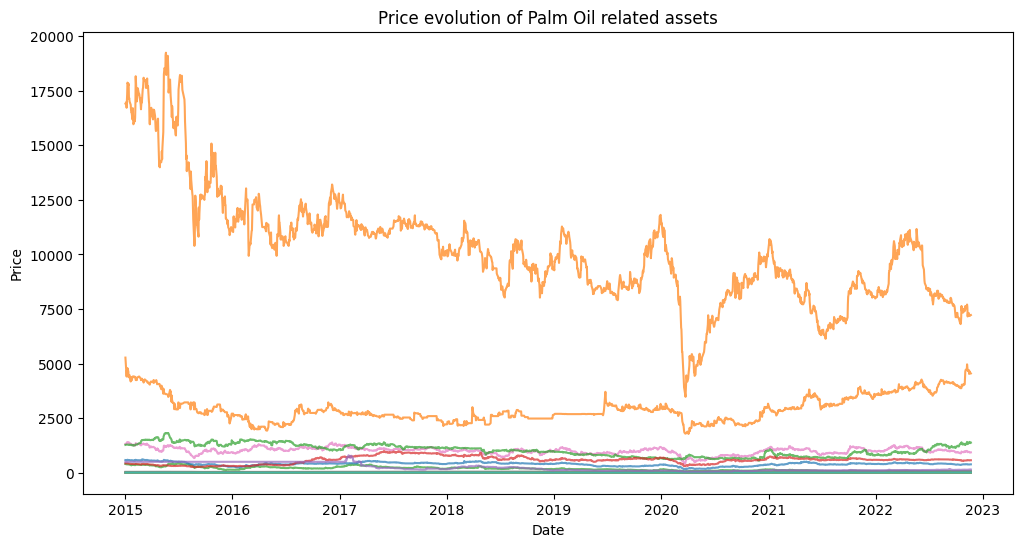

In [ ]:
plt.figure(figsize=(12,6))

for column in data.columns:
    plt.plot(data.index, data[column], alpha=0.7)

plt.title("Price evolution of Palm Oil related assets")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## Split the Dataset into Formation and Trading Periods

In quantitative trading, it is important to separate the data into two parts :

- Formation period : used to study relationships between assets
- Trading period : used to test the strategy

The formation period is used to compute statistics such as correlation, cointegration, mean, and standard deviation.

The trading period is used for the backtest.

In [ ]:
formation_data = data.loc["2015-01-01":"2020-12-31"].copy()
trading_data = data.loc["2021-01-01":].copy()

print("Formation period shape:", formation_data.shape)
print("Trading period shape:", trading_data.shape)

print("Formation start:", formation_data.index.min())
print("Formation end:", formation_data.index.max())

print("Trading start:", trading_data.index.min())
print("Trading end:", trading_data.index.max())

Formation period shape: (1424, 15)
Trading period shape: (445, 15)
Formation start: 2015-01-02 00:00:00
Formation end: 2020-12-30 00:00:00
Trading start: 2021-01-04 00:00:00
Trading end: 2022-11-21 00:00:00


## Correlation Analysis

The first step of the screening process is to check whether the assets move together.

We compute the Pearson correlation matrix on the formation period.

High correlation does not guarantee a tradable relationship, but it is a useful first filter before the cointegration test.

In [ ]:
# Correlation matrix on the formation period

correlation_matrix = formation_data.corr()
correlation_matrix.round(2)

,5JS.SI,AALI.JK,BWPT.JK,DBA,E5H.SI,EB5.SI,LSIP.JK,MOO,P8Z.SI,RJA,SIMP.JK,SMAR.JK,SSMS.JK,TBLA.JK,UNSP.JK
5JS.SI,1.00,0.83,0.75,0.82,0.70,0.47,0.60,-0.66,0.72,0.75,0.51,0.56,0.75,-0.29,0.74
AALI.JK,0.83,1.00,0.80,0.87,0.72,0.60,0.77,-0.51,0.89,0.85,0.74,0.69,0.77,-0.20,0.73
BWPT.JK,0.75,0.80,1.00,0.84,0.79,0.57,0.69,-0.52,0.82,0.84,0.82,0.47,0.79,0.01,0.70
DBA,0.82,0.87,0.84,1.00,0.86,0.56,0.71,-0.74,0.82,0.95,0.73,0.47,0.91,-0.18,0.88
E5H.SI,0.70,0.72,0.79,0.86,1.00,0.73,0.74,-0.61,0.78,0.79,0.73,0.36,0.81,0.14,0.72
EB5.SI,0.47,0.60,0.57,0.56,0.73,1.00,0.71,-0.30,0.75,0.49,0.57,0.30,0.49,0.29,0.39
LSIP.JK,0.60,0.77,0.69,0.71,0.74,0.71,1.00,-0.34,0.77,0.70,0.71,0.47,0.57,0.18,0.57
MOO,-0.66,-0.51,-0.52,-0.74,-0.61,-0.30,-0.34,1.00,-0.41,-0.57,-0.25,-0.15,-0.79,0.43,-0.82
P8Z.SI,0.72,0.89,0.82,0.82,0.78,0.75,0.77,-0.41,1.00,0.77,0.78,0.63,0.70,-0.07,0.63
RJA,0.75,0.85,0.84,0.95,0.79,0.49,0.70,-0.57,0.77,1.00,0.78,0.43,0.84,-0.07,0.82


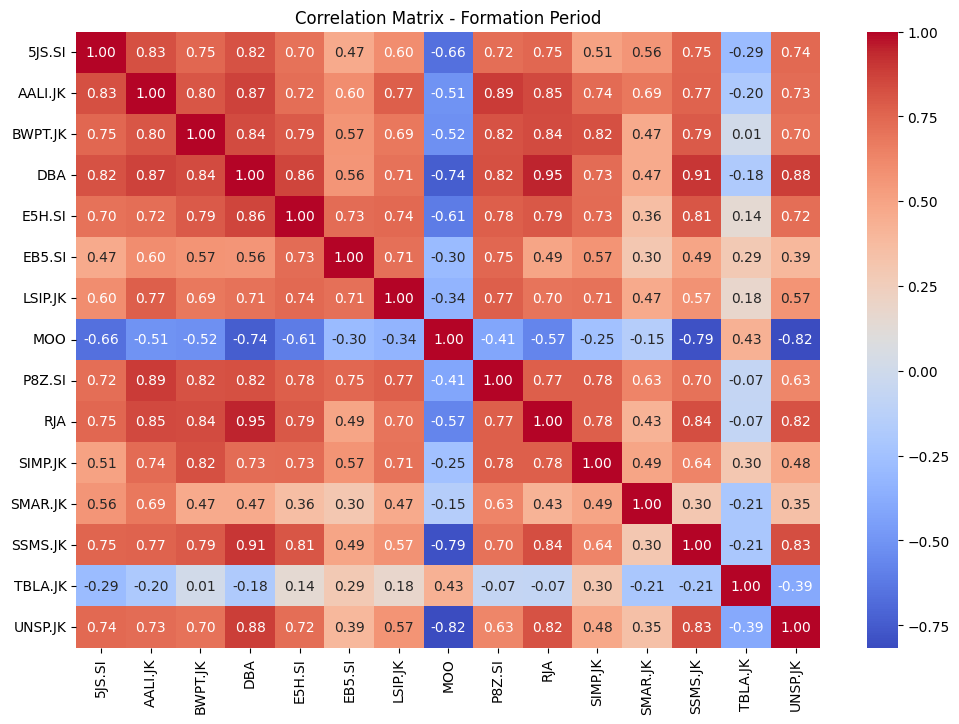

In [ ]:
# Plot the correlation heatmap

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Formation Period")
plt.show()

## Select Candidate Stocks for Game 1

According to the project instructions, Game 1 must be implemented on a set of 4–5 stocks from the commodity universe.

These stocks should be economically related to the core index/anchor and should exhibit meaningful statistical relationships during the formation period.

In this notebook, we first define a core index and then study the cointegration relationship between the index and the selected stocks.

In [ ]:
# Define the core index/anchor and the stock universe for Game1
# We use 5 assets to stay close to the project requirement
core_index = "RJA"

selected_stocks = ["AALI.JK", "LSIP.JK", "SIMP.JK", "SMAR.JK", "SSMS.JK"]

formation_core = formation_data[[core_index] + selected_stocks].copy()
trading_core = trading_data[[core_index] + selected_stocks].copy()

print("Core index:", core_index)
print("Selected stocks:", selected_stocks)

formation_core.head()

Core index: RJA
Selected stocks: ['AALI.JK', 'LSIP.JK', 'SIMP.JK', 'SMAR.JK', 'SSMS.JK']


,RJA,AALI.JK,LSIP.JK,SIMP.JK,SMAR.JK,SSMS.JK
Date,,,,,,
2015-01-02,7.2900,16904.500000,1323.021606,580.742249,5272.602539,1274.376587
2015-01-05,7.4300,16973.289062,1340.384155,576.681091,4565.301758,1289.457764
2015-01-06,7.4301,16715.332031,1319.549194,568.558716,4404.551758,1289.457764
2015-01-07,7.3900,16990.486328,1329.966553,564.497681,4693.901855,1289.457764
2015-01-08,7.3699,17351.615234,1402.889038,588.864563,4693.901855,1289.457764


## Correlation Matrix: Core Index and Selected Stocks

We now focus on the core index and the selected stocks.

This helps us verify whether the selected equities move in a related way with the commodity-related anchor.

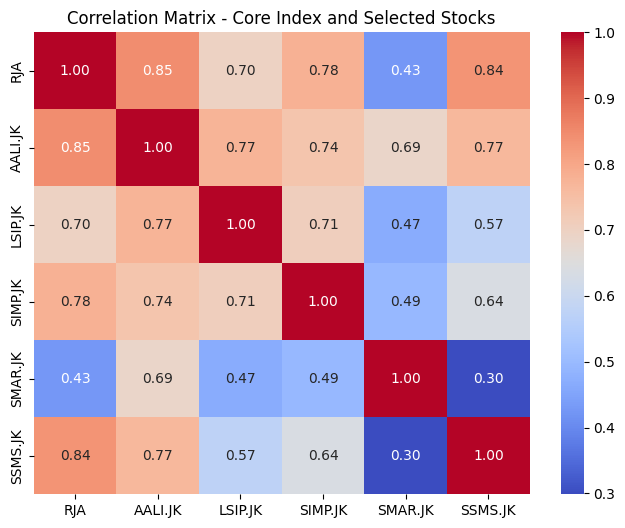

In [ ]:
selected_corr = formation_core.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(selected_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Core Index and Selected Stocks")
plt.show()

## Cointegration Test with the Core Index

We select stocks that are cointegrated with the core index.

For this reason, we perform the Engle-Granger cointegration test between the core index and each selected stock during the formation period.

In [ ]:
cointegration_results = []

for stock in selected_stocks:
    score, pvalue, _ = coint(formation_core[core_index], formation_core[stock])

    cointegration_results.append({"Core Index": core_index, "Stock": stock, "Test Statistic": score, "p-value": pvalue
    })

cointegration_df = pd.DataFrame(cointegration_results).sort_values(by="p-value")
cointegration_df

,Core Index,Stock,Test Statistic,p-value
4,RJA,SSMS.JK,-4.145062,0.004412
0,RJA,AALI.JK,-3.671592,0.019924
1,RJA,LSIP.JK,-2.969005,0.117758
2,RJA,SIMP.JK,-2.874368,0.143165
3,RJA,SMAR.JK,-2.129901,0.460750


## Select the Stocks for the Market-Neutral Basket

We keep the stocks with the strongest cointegration relationship with the core index.

These assets will be used to construct the multivariate basket for Game 1.

In [ ]:
# Keep the selected basket stocks
# Here we keep all 5 stocks, but the ranking is shown for transparency

basket_stocks = cointegration_df["Stock"].tolist()

print("Core index:", core_index)
print("Basket stocks:", basket_stocks)

Core index: RJA
Basket stocks: ['SSMS.JK', 'AALI.JK', 'LSIP.JK', 'SIMP.JK', 'SMAR.JK']


## Build Relative Spreads versus the Core Index

Instead of focusing on a single trading pair, we compute the log spread between each selected stock and the core index.

This allows us to monitor multiple relative deviations inside the basket.

In [ ]:
spread_df = pd.DataFrame(index=trading_core.index)

for stock in basket_stocks:
    spread_df[stock] = np.log(trading_core[stock]) - np.log(trading_core[core_index])

spread_df.head()

,SSMS.JK,AALI.JK,LSIP.JK,SIMP.JK,SMAR.JK
Date,,,,,
2021-01-04,5.060874,7.408445,5.177102,4.073872,6.119686
2021-01-05,5.073159,7.373067,5.136856,4.035071,6.084879
2021-01-06,5.064860,7.364183,5.143825,4.063871,6.087590
2021-01-07,5.079233,7.384706,5.181947,4.089274,6.082736
2021-01-08,5.062506,7.392719,5.201734,4.121564,6.078214


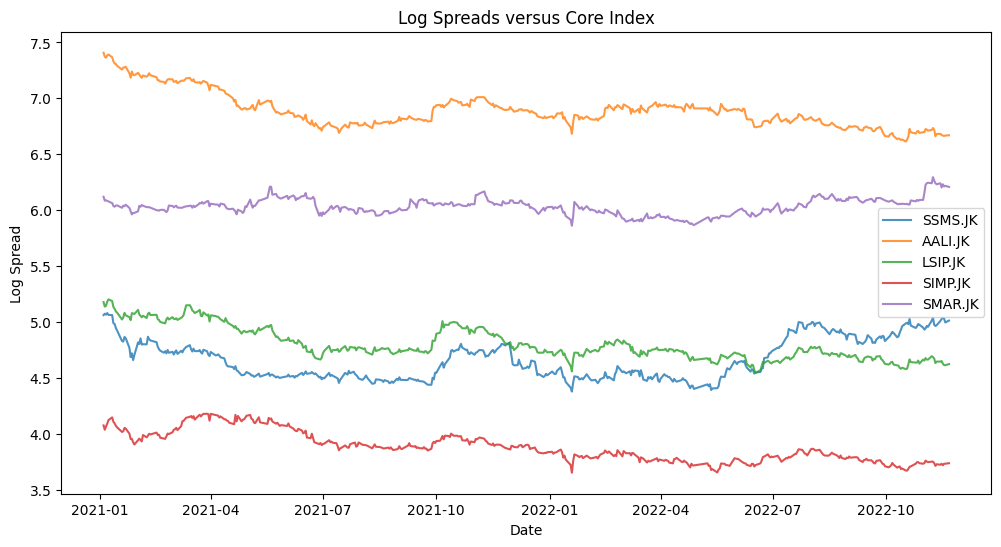

In [ ]:
plt.figure(figsize=(12, 6))

for stock in basket_stocks:
    plt.plot(spread_df.index, spread_df[stock], label=stock, alpha=0.8)

plt.title("Log Spreads versus Core Index")
plt.xlabel("Date")
plt.ylabel("Log Spread")
plt.legend()
plt.show()

## Compute Z-Scores for Each Spread

To detect abnormal deviations, each spread is normalized using its z-score.

This gives us a standardized measure of relative mispricing for each stock against the core index.

In [ ]:
zscore_df = pd.DataFrame(index=spread_df.index)

for stock in basket_stocks:
    mean_spread = spread_df[stock].mean()
    std_spread = spread_df[stock].std()
    zscore_df[stock] = (spread_df[stock] - mean_spread) / std_spread

zscore_df.head()

,SSMS.JK,AALI.JK,LSIP.JK,SIMP.JK,SMAR.JK
Date,,,,,
2021-01-04,2.194854,3.301195,2.568503,1.438327,1.185614
2021-01-05,2.263097,3.076468,2.293881,1.147658,0.704258
2021-01-06,2.216997,3.020037,2.341436,1.363407,0.741756
2021-01-07,2.296838,3.150404,2.601564,1.553707,0.674629
2021-01-08,2.203922,3.201304,2.736584,1.795607,0.612096


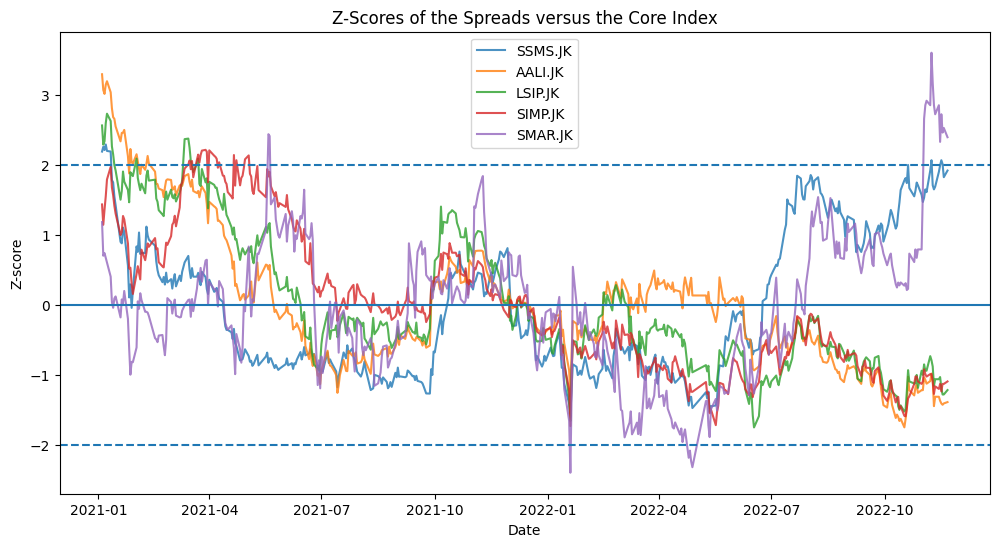

In [ ]:
plt.figure(figsize=(12, 6))

for stock in basket_stocks:
    plt.plot(zscore_df.index, zscore_df[stock], label=stock, alpha=0.8)

plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.axhline(0, linestyle="-")
plt.title("Z-Scores of the Spreads versus the Core Index")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()
plt.show()

## Trading Signals for the Basket

For each stock, we use the z-score of the spread versus the core index.
- if the z-score is high, the stock is considered relatively overpriced
- if the z-score is low, the stock is considered relatively underpriced

These signals are then used in the portfolio optimization step.

In [ ]:
open_threshold = 2.0

signal_df = pd.DataFrame(index=zscore_df.index)

for stock in basket_stocks:
    signal_df[stock] = 0
    signal_df.loc[zscore_df[stock] > open_threshold, stock] = -1
    signal_df.loc[zscore_df[stock] < -open_threshold, stock] = 1

signal_df.head()

,SSMS.JK,AALI.JK,LSIP.JK,SIMP.JK,SMAR.JK
Date,,,,,
2021-01-04,-1,-1,-1,0,0
2021-01-05,-1,-1,-1,0,0
2021-01-06,-1,-1,-1,0,0
2021-01-07,-1,-1,-1,0,0
2021-01-08,-1,-1,-1,0,0


## From Signals to Portfolio Weights

At this stage, we have entry signals for each stock relative to the core index.

The next step is to transform these signals into optimized portfolio weights while enforcing market neutrality.

In [ ]:
signal_count = (signal_df != 0).sum()
signal_count

,0
SSMS.JK,10
AALI.JK,24
LSIP.JK,16
SIMP.JK,19
SMAR.JK,21


## Portfolio Optimization and Backtest

We now convert the trading signals into portfolio weights.

According to the project instructions, the basket must be market-neutral and optimized to minimize risk while respecting the neutrality constraint.

We also include transaction costs and compare the strategy with a simple benchmark.

## Compute Asset Returns

We now compute daily log returns for the core index and the selected basket stocks.

The formation-period returns will be used to estimate the covariance matrix for the optimization step.

The trading-period returns will be used for the backtest.

In [ ]:
assets = [core_index] + basket_stocks

formation_returns = np.log(formation_core[assets] / formation_core[assets].shift(1)).dropna()
trading_returns = np.log(trading_core[assets] / trading_core[assets].shift(1)).dropna()

print("Formation returns shape:", formation_returns.shape)
print("Trading returns shape:", trading_returns.shape)

formation_returns.head()

Formation returns shape: (1423, 6)
Trading returns shape: (444, 6)


,RJA,SSMS.JK,AALI.JK,LSIP.JK,SIMP.JK,SMAR.JK
Date,,,,,,
2015-01-05,0.019022,0.011765,0.004061,0.013038,-0.007018,-0.144039
2015-01-06,0.000013,0.000000,-0.015314,-0.015666,-0.014185,-0.035846
2015-01-07,-0.005412,0.000000,0.016327,0.007864,-0.007168,0.063626
2015-01-08,-0.002724,0.000000,0.021032,0.053380,0.042260,0.000000
2015-01-09,0.001098,-0.002928,0.029299,0.000000,0.006873,0.020340


## Covariance Matrix

Following the project logic, we estimate portfolio risk using the covariance matrix of asset returns.

This covariance matrix is computed on the formation period and will be used in the portfolio optimization.

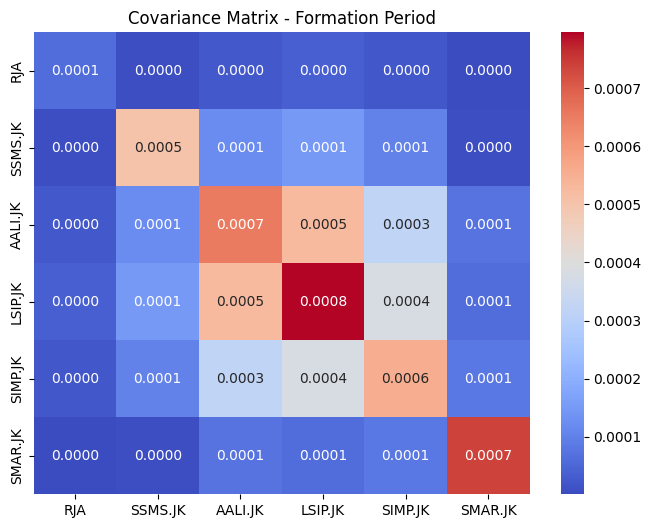

In [ ]:
cov_matrix = formation_returns.cov()

plt.figure(figsize=(8, 6))
sns.heatmap(cov_matrix, annot=True, cmap="coolwarm", fmt=".4f")
plt.title("Covariance Matrix - Formation Period")
plt.show()

## Optimization Function

We now define the optimization problem.

The objective is to construct a market-neutral portfolio :

- maximize signal-based expected return
- minimize portfolio risk
- enforce the neutrality constraint
- include position limits

The neutrality condition is implemented as: Pβ = 0 where P is the vector of current prices and β is the vector of portfolio weights.

In [ ]:
def optimize_weights_gurobi(signals_today, prices_today, cov_matrix, core_index, basket_stocks, risk_aversion=10.0, max_weight=0.30, gross_limit=1.00):


    assets = [core_index] + basket_stocks
    active_signals = signals_today.abs().sum()

    # if no active signal, return zero weights
    if active_signals == 0:
        return pd.Series(0.0, index=assets)

    # signal-based alpha:
    # core index has no direct alpha signal, only hedge role
    alpha = {core_index: 0.0}
    for stock in basket_stocks:
        alpha[stock] = float(signals_today[stock])

    model = gp.Model("market_neutral_basket")
    model.setParam("OutputFlag", 0)

    # portfolio weights
    w = model.addVars(assets, lb=-max_weight, ub=max_weight, name="w")

    # absolute values for gross exposure control
    u = model.addVars(assets, lb=0.0, name="u")

    # objective: maximize alpha - lambda * risk
    alpha_term = gp.quicksum(alpha[a] * w[a] for a in assets)

    risk_term = gp.quicksum(
        w[a] * cov_matrix.loc[a, b] * w[b]
        for a in assets for b in assets
    )

    model.setObjective(alpha_term - risk_aversion * risk_term, GRB.MAXIMIZE)

    # absolute value constraints
    for a in assets:
        model.addConstr(u[a] >= w[a])
        model.addConstr(u[a] >= -w[a])

    # gross exposure constraint
    model.addConstr(gp.quicksum(u[a] for a in assets) <= gross_limit)

    # market-neutrality constraint: Pβ = 0
    model.addConstr(gp.quicksum(float(prices_today[a]) * w[a] for a in assets) == 0)

    model.optimize()

    if model.status == GRB.OPTIMAL:
        weights = pd.Series({a: w[a].X for a in assets})
    else:
        weights = pd.Series(0.0, index=assets)

    return weights

## Daily Portfolio Weights

We now apply the optimization day by day during the trading period.

For each dya

1. we read the signal of each stock
2. we use current prices
3. we solve the optimization problem
4. we store the optimal portfolio weights

In [ ]:
weights_list = []

common_index = trading_returns.index.intersection(signal_df.index)

for date in common_index:
    signals_today = signal_df.loc[date, basket_stocks]
    prices_today = trading_core.loc[date, assets]

    weights_today = optimize_weights_gurobi(
        signals_today=signals_today,
        prices_today=prices_today,
        cov_matrix=cov_matrix.loc[assets, assets],
        core_index=core_index,
        basket_stocks=basket_stocks,
        risk_aversion=10.0,
        max_weight=0.30,
        gross_limit=1.00
    )

    weights_today.name = date
    weights_list.append(weights_today)

weights_df = pd.DataFrame(weights_list)
weights_df.head()

Restricted license - for non-production use only - expires 2027-11-29


,RJA,SSMS.JK,AALI.JK,LSIP.JK,SIMP.JK,SMAR.JK
2021-01-05,8.450263e-10,-0.3,-0.023315,-0.3,0.076685,0.3
2021-01-06,1.530748e-10,-0.3,-0.023835,-0.3,0.076165,0.3
2021-01-07,2.119105e-11,-0.3,-0.021446,-0.3,0.078554,0.3
2021-01-08,1.377332e-11,-0.3,-0.020862,-0.3,0.079138,0.3
2021-01-11,1.013140e-11,-0.3,-0.020804,-0.3,0.079196,0.3


## Strategy Returns with Transaction Costs

We now backtest the optimized basket.

To avoid look-ahead bias, we use the weights from the previous day.

We also include transaction costs of 10 basis points (0.1%), as required in the project instructions.

In [ ]:
transaction_cost = 0.001

aligned_returns = trading_returns.loc[weights_df.index, assets].copy()

# use previous-day weights
shifted_weights = weights_df.shift(1).fillna(0)

# gross portfolio return
gross_strategy_return = (shifted_weights * aligned_returns).sum(axis=1)

# turnover for transaction costs
turnover = weights_df.diff().abs().sum(axis=1).fillna(0)

# net strategy return
net_strategy_return = gross_strategy_return - transaction_cost * turnover

strategy_df = pd.DataFrame(index=weights_df.index)
strategy_df["gross_return"] = gross_strategy_return
strategy_df["turnover"] = turnover
strategy_df["net_return"] = net_strategy_return

strategy_df.head()

,gross_return,turnover,net_return
2021-01-05,0.000000,0.000000,0.000000
2021-01-06,0.006226,0.001041,0.006225
2021-01-07,-0.015008,0.004777,-0.015013
2021-01-08,0.001569,0.001169,0.001568
2021-01-11,0.002590,0.000116,0.002590


## Benchmark Strategy

The project asks to compare the optimized basket with a simple benchmark.

Here we use a simple equal-weight signal-based benchmark :

- equal weights across active stock signals
- core index used as hedge
- same market-neutrality idea

In [ ]:
def build_benchmark_weights(signals_today, prices_today, core_index, basket_stocks, gross_limit=1.0):
    assets = [core_index] + basket_stocks
    w = pd.Series(0.0, index=assets)

    active = signals_today[signals_today != 0]

    if len(active) == 0:
        return w

    # equal weights on active stocks
    stock_weight = 0.8 / len(active)

    for stock, signal in active.items():
        w[stock] = stock_weight * signal

    # hedge with core index so that Pβ = 0
    stock_value = sum(prices_today[s] * w[s] for s in basket_stocks)
    w[core_index] = -stock_value / prices_today[core_index]

    # rescale if gross exposure is too large
    gross_exposure = w.abs().sum()
    if gross_exposure > gross_limit:
        w = w / gross_exposure * gross_limit

    return w


benchmark_weights_list = []

for date in common_index:
    signals_today = signal_df.loc[date, basket_stocks]
    prices_today = trading_core.loc[date, assets]

    w_bench = build_benchmark_weights(
        signals_today=signals_today,
        prices_today=prices_today,
        core_index=core_index,
        basket_stocks=basket_stocks,
        gross_limit=1.0
    )

    w_bench.name = date
    benchmark_weights_list.append(w_bench)

benchmark_weights_df = pd.DataFrame(benchmark_weights_list)

benchmark_shifted = benchmark_weights_df.shift(1).fillna(0)
benchmark_gross_return = (benchmark_shifted * aligned_returns).sum(axis=1)
benchmark_turnover = benchmark_weights_df.diff().abs().sum(axis=1).fillna(0)
benchmark_net_return = benchmark_gross_return - transaction_cost * benchmark_turnover

strategy_df["benchmark_return"] = benchmark_net_return
strategy_df.head()

,gross_return,turnover,net_return,benchmark_return
2021-01-05,0.000000,0.000000,0.000000,0.000000
2021-01-06,0.006226,0.001041,0.006225,-0.010496
2021-01-07,-0.015008,0.004777,-0.015013,-0.003059
2021-01-08,0.001569,0.001169,0.001568,-0.006075
2021-01-11,0.002590,0.000116,0.002590,0.001542


## Cumulative Performance

We now compare the cumulative performance of the optimized market-neutral basket and the simple benchmark

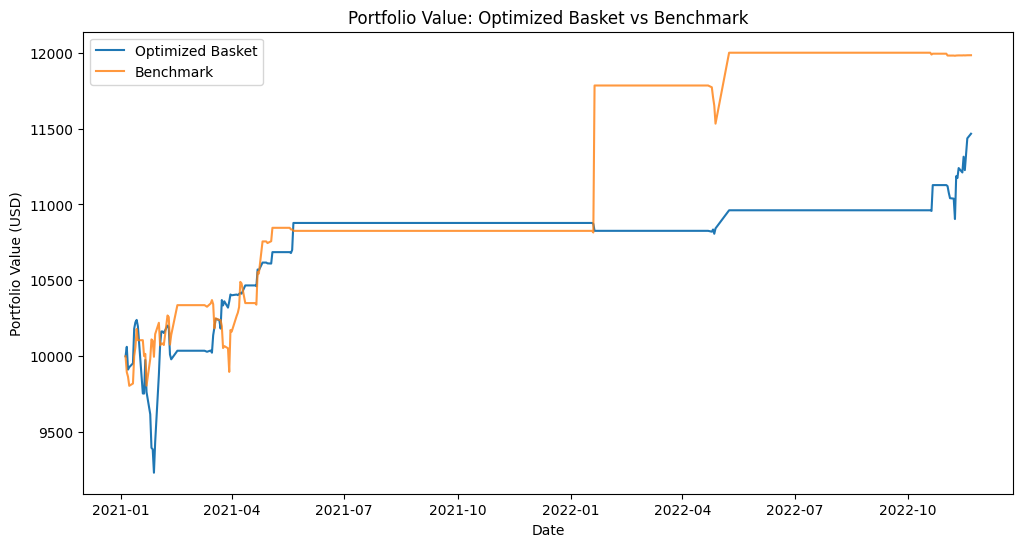

In [ ]:
strategy_df["cum_strategy"] = strategy_df["net_return"].cumsum()
strategy_df["cum_benchmark"] = strategy_df["benchmark_return"].cumsum()

initial_capital = 10000
strategy_df["portfolio_strategy"] = initial_capital * np.exp(strategy_df["cum_strategy"])
strategy_df["portfolio_benchmark"] = initial_capital * np.exp(strategy_df["cum_benchmark"])

plt.figure(figsize=(12, 6))
plt.plot(strategy_df.index, strategy_df["portfolio_strategy"], label="Optimized Basket")
plt.plot(strategy_df.index, strategy_df["portfolio_benchmark"], label="Benchmark", alpha=0.8)

plt.title("Portfolio Value: Optimized Basket vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (USD)")
plt.legend()
plt.show()

## Performance Metrics

We report a few standard performance indicators :

- total return
- annualized return
- annualized volatility
- Sharpe ratio
- maximum drawdown

In [ ]:
def compute_metrics(return_series, trading_days=252):
    return_series = return_series.dropna()

    cumulative_log_return = return_series.sum()
    total_return = np.exp(cumulative_log_return) - 1

    annualized_return = np.exp(return_series.mean() * trading_days) - 1
    annualized_volatility = return_series.std() * np.sqrt(trading_days)

    if annualized_volatility != 0:
        sharpe_ratio = annualized_return / annualized_volatility
    else:
        sharpe_ratio = np.nan

    cumulative_curve = np.exp(return_series.cumsum())
    rolling_max = cumulative_curve.cummax()
    drawdown = (cumulative_curve - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    return {
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_drawdown
    }


metrics_strategy = compute_metrics(strategy_df["net_return"])
metrics_benchmark = compute_metrics(strategy_df["benchmark_return"])

metrics_df = pd.DataFrame([metrics_strategy, metrics_benchmark], index=["Optimized Basket", "Benchmark"])
metrics_df = metrics_df.applymap(lambda x: round(x, 4))

metrics_df

/tmp/ipykernel_168/3661896375.py:33: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  metrics_df = metrics_df.applymap(lambda x: round(x, 4))


,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Optimized Basket,0.1466,0.0807,0.0787,1.0262,-0.0983
Benchmark,0.1983,0.1081,0.0936,1.1552,-0.0456
